In [1]:
import pandas as pd
import glob
import os

# Ищем все CSV‑файлы в текущей директории
file_paths = glob.glob("data/*.csv")  # или укажите полный путь

# Словарь для хранения цен закрытия по каждой криптовалюте
close_prices = {}

for file_path in file_paths:
    # Извлекаем имя криптовалюты из имени файла (без расширения)
    crypto_name = os.path.splitext(os.path.basename(file_path))[0]

    # Загружаем датасет
    df = pd.read_csv(file_path)

    # Проверяем наличие столбца 'close' (возможны варианты написания)
    if 'close' in df.columns:
        close_prices[crypto_name] = df['close']
    elif 'Close' in df.columns:
        close_prices[crypto_name] = df['Close']
    else:
        print(f"Предупреждение: в файле {file_path} нет столбца 'close' или 'Close'")

# Создаём DataFrame, где колонки — криптовалюты, строки — даты/индексы
prices_df = pd.DataFrame(close_prices)


In [3]:
prices_df

,AAVEUSDT_1h_last_year,ADAUSDT_1h_last_year,ALGOUSDT_1h_last_year,APTUSDT_1h_last_year,ARBUSDT_1h_last_year,ASTERUSDT_1h_last_year,ATOMUSDT_1h_last_year,AVAXUSDT_1h_last_year,BCHUSDT_1h_last_year,BNBUSDT_1h_last_year,...,UUSDT_1h_last_year,VETUSDT_1h_last_year,VIRTUALUSDT_1h_last_year,WLDUSDT_1h_last_year,WLFIUSDT_1h_last_year,XLMUSDT_1h_last_year,XRPUSDT_1h_last_year,XTZUSDT_1h_last_year,ZECUSDT_1h_last_year,ZROUSDT_1h_last_year
0,183.22,0.7322,0.1942,5.437,0.3434,2.143,3.947,17.79,344.8,557.13,...,1.0008,0.024340,0.5307,0.8100,0.2798,0.2589,2.1948,0.6750,30.54,1.704
1,182.08,0.7241,0.1913,5.309,0.3377,2.062,3.884,17.51,340.2,551.61,...,1.0007,0.023960,0.5245,0.7990,0.2580,0.2553,2.1711,0.6730,30.29,1.673
2,179.62,0.7268,0.1921,5.290,0.3355,2.091,3.875,17.37,336.8,552.14,...,1.0007,0.023810,0.5303,0.7960,0.2541,0.2567,2.1812,0.6820,30.35,1.671
3,181.94,0.7416,0.1955,5.322,0.3406,2.128,3.917,17.65,343.1,555.01,...,1.0009,0.024150,0.5308,0.8080,0.2475,0.2606,2.2301,0.6730,30.52,1.691
4,177.51,0.7284,0.1922,5.197,0.3350,2.120,3.856,17.33,334.7,549.40,...,1.0003,0.023750,0.5261,0.7940,0.2491,0.2575,2.1958,0.6630,29.91,1.672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,111.99,0.2650,0.0865,0.941,0.1012,NaN,1.838,9.68,457.0,651.76,...,NaN,0.007132,NaN,0.3580,NaN,0.1602,1.3981,0.3681,211.87,2.135
8756,112.42,0.2663,0.0868,0.946,0.1018,NaN,1.846,9.74,457.3,652.68,...,NaN,0.007164,NaN,0.3600,NaN,0.1607,1.4044,0.3665,213.24,2.143
8757,112.25,0.2652,0.0865,0.943,0.1012,NaN,1.838,9.70,457.8,653.15,...,NaN,0.007152,NaN,0.3590,NaN,0.1600,1.3901,0.3652,213.92,2.148
8758,111.47,0.2641,0.0866,0.943,0.1007,NaN,1.832,9.67,457.0,652.78,...,NaN,0.007135,NaN,0.3578,NaN,0.1602,1.3916,0.3660,213.39,2.142


In [4]:
start_dates = {}
for col in prices_df.columns:
    # Ищем первый не-NaN индекс
    first_valid = prices_df[col].first_valid_index()
    start_dates[col] = first_valid

In [5]:
common_start = max(start_dates.values())
prices_common = prices_df.loc[common_start:].copy()

In [6]:
prices_clean = prices_common.dropna(axis=1)  # Удаляем монеты без данных в общем периоде

In [7]:
# Матрица корреляции Пирсона (по умолчанию)
correlation_matrix = prices_clean.corr(method='pearson')

# Другие методы (при необходимости):
# Спирмена (для монотонных зависимостей, устойчивее к выбросам)
# correlation_matrix = prices_df_clean.corr(method='spearman')
# Кендалла (ранговая корреляция)
# correlation_matrix = prices_df_clean.corr(method='kendall')


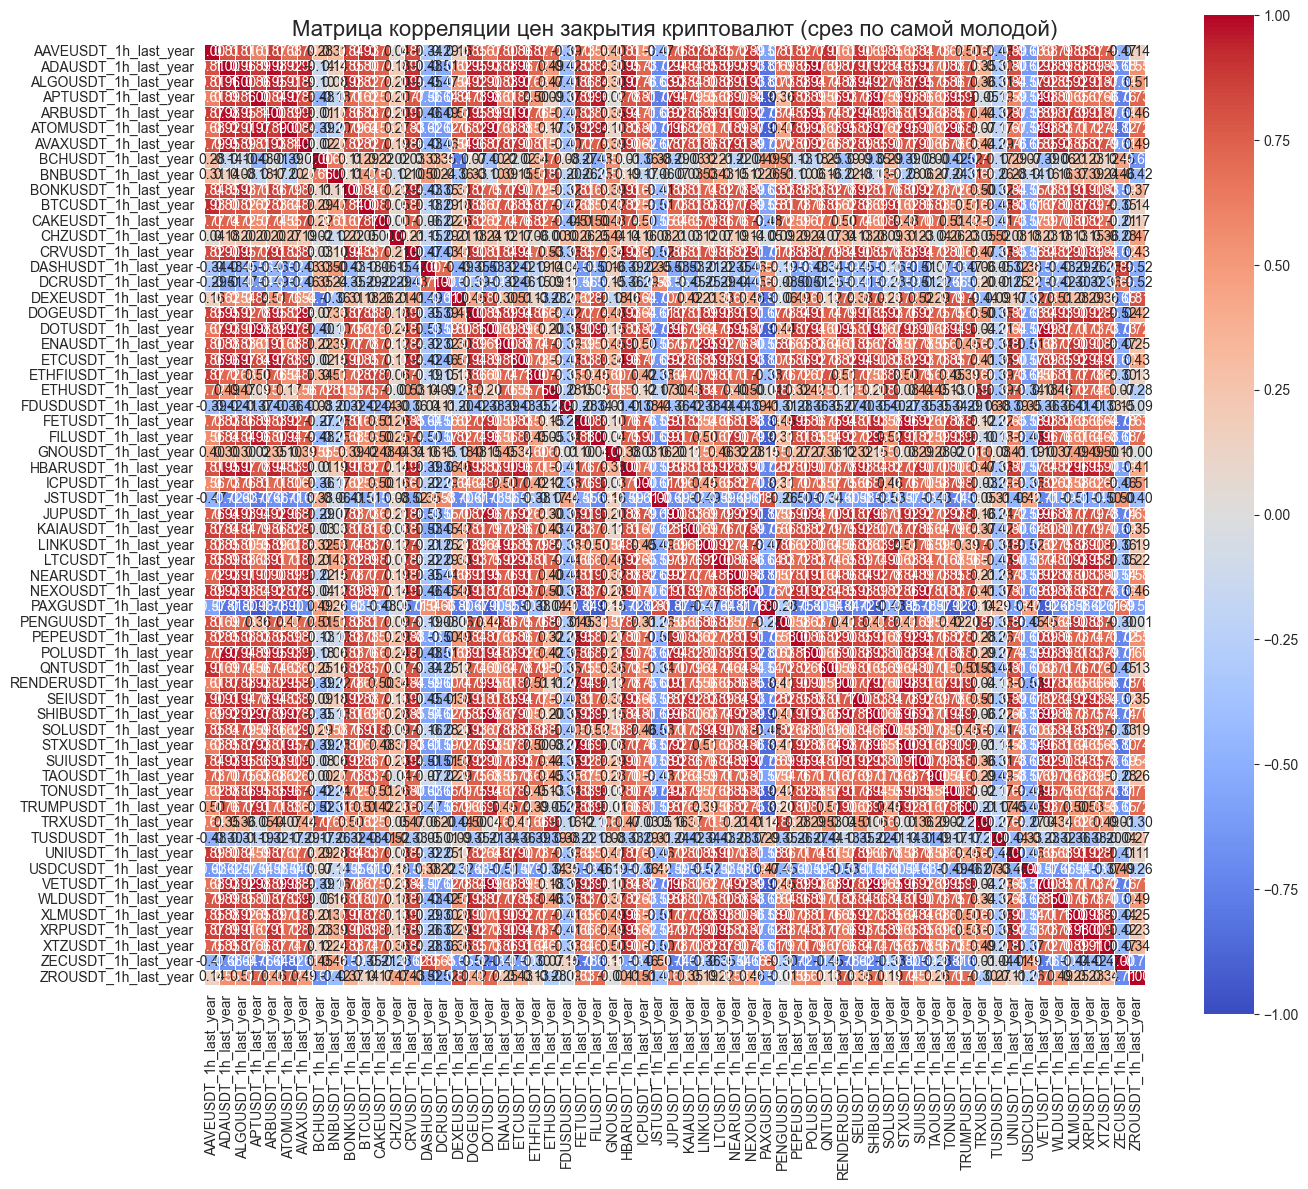

Матрица сохранена как 'correlation_matrix.png'


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,           # Показывать значения в ячейках
    cmap='coolwarm',       # Цветовая схема: красный — положительная, синий — отрицательная
    vmin=-1, vmax=1,   # Диапазон значений корреляции
    center=0,           # Центр цветовой шкалы
    square=True,         # Квадратные ячейки
    linewidths=0.5,     # Толщина линий между ячейками
    fmt='.2f'           # Формат чисел (2 знака после запятой)
)
plt.title('Матрица корреляции цен закрытия криптовалют (срез по самой молодой)', fontsize=16)
plt.tight_layout()

# Сохраняем как картинку
plt.savefig('plots/correlation_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()  # Закрываем фигуру, чтобы освободить память
print("Матрица сохранена как 'correlation_matrix.png'")




In [14]:
import numpy as np
if correlation_matrix.empty or correlation_matrix.isnull().all().all():
    print("Ошибка: невозможно создать матрицу корреляций")
else:
    # Создание графика
    plt.figure(figsize=(16, 14))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(
        correlation_matrix,
        mask=mask,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        fmt='.2f',
        cbar_kws={"shrink": .8}
    )
    plt.title('Корреляция цен закрытия криптовалют', fontsize=18, pad=20)
    plt.tight_layout()

    # Сохранение
    plt.savefig('plots/crypto_correlation_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("Матрица успешно сохранена как 'crypto_correlation_heatmap.png'")

Матрица успешно сохранена как 'crypto_correlation_heatmap.png'
